# [Crategraph](https://github.com/unimelbmdap/cdl2-rocrates) Cheat Sheet

**Crategraph basics**

> Inspired by Franz Diebold's Polars cheat sheet (cheat sheet will eventually look similar).


## Before we begin...

A `crate` from Crategraph Python package is a **`Graph`** consisting of two layers of data:

```
        ENTITY (node)              RELATIONSHIP (edge)
        ┌────────────┐  --type-->  ┌──────────────┐
        │ .id .types │ ══════════> │ .type         │
        │ .properties│             │ .source/.target│
        │ .name      │             │ .properties    │
        └────────────┘             └──────────────┘
              │                            │
     filter by PROPERTIES         filter by STRUCTURE
        crate.where(...)            crate.select(...)
```

**It's important to keep in mind:** the layer you query must match the method.

| Filtering by… | Method to use | Example |
|---|---|---|
| a value *on a node* (name, year, nationality) | `where` | `crate.where(name="Smith")` |
| a *type* or *edge* (entity_types, relationship_types) | `select` | `crate.select(relationship_types="Primary")` |

For example, running `where(relationship_types="Primary")` returns **0** (it looks for a node *property* literally called `relationship_types`, which doesn't exist).

**Remember:** every filter/transform returns a **new `Graph`**, so they chain.

We will explore crategraph package together below

#### Case Study: The University of Melbourne Perpetual Calendar (UMPC) RO-Crate

**Source:** https://umpc.esrc.unimelb.edu.au

## Import/Install

Make sure crategraph package is up to date and import it:

In [233]:
!git pull

Already up to date.


## Load a graph


In [235]:
from crategraph import Crate

Load your graph (RO-Crate) from a local directory pointing at ro-crate-metadata.json
<br>
crate = Crate("path/to/your/crate/")
<br>
Crate represents a Graph (N entities, M relationships)

In [236]:
crate = Crate(
    "/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate"
)

In [237]:
# Options:
#   Crate(p1, p2)              -> load several crates (IDs prefixed by dir name)
#   Crate(path, include_root=True)
#   Crate(path, inline_relations=False)   # only reified Relationship entities

You can get a quick "feel" about your crate using these methods:

Summary of a graph including a complete list of entity types and relationship counts:

In [238]:
crate.summary()

=== Graph Summary ===
Source: /Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate
Entities: 4270 | Relationships: 12601

Entity types:
  PublishedResource, Resource                  1068  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  Regulations_and Statutes                      751  ▒▒▒▒▒▒▒▒▒▒▒
  Person                                        554  ▒▒▒▒▒▒▒▒
  Person, University of Melbourne               317  ▒▒▒▒
  Role                                          200  ▒▒▒
  Place                                         178  ▒▒
  Key_Resource                                  161  ▒▒
  Academic_Unit                                 137  ▒▒
  Grouping                                      134  ▒▒
  Function                                      125  ▒▒
  Organisation                                  122  ▒▒
  PublishedResource, BookSection                105  ▒
  PublishedResource, NewspaperArticle            80  ▒
  PublishedResource, ResourceSection             55  ▒
  Individual_Story                               42  ▒
  State                                          33  
  Activity                                       32  
  Event                                          32  
  Administrative_Unit                            32  
  Person, Education                              19  
  PublishedResource, Report                      11  
  RepositoryObject, DigitalObject, Document       7  
  File, DigitalObject, Document                   7  
  Industry_Grouping                               7  
  Person, Occupation                              7  
  Course                                          7  
  PublishedResource, JournalArticle               7  
  PublishedResource, Book                         7  
  T, h, i, n, g, University of Melbourne          6  
  Person, Scholarships                            3  
  PublishedResource, ResourceSection, Website     3  
  Dataset                                         3  
  CreativeWork                                    2  
  Person, Residence                               2  
  PublishedResource, Resource, Website            2  
  Nationality                                     1  
  also known as                                   1  
  Person, Trinity College                         1  
  Person, Life Event                              1  
  Person, Ormond College                          1  
  Person, Public Life                             1  
  Person, Military                                1  
  PublishedResource, ConferencePaper              1  
  PublishedResource, Journal                      1  
  PublishedResource, Article                      1  
  PublishedResource, Thesis, MAEd thesis          1  
  PublishedResource, EditedBook                   1  

Relationship types:
  Related        9743  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  Relationship   1249  ▒▒
  relatedEvents   358  ▒
  entity          358  ▒
  preparedBy      261  
  birthPlace      176  
  birthState      152  
  deathPlace      126  
  deathState      120  
  Previous         12  
  Subsequent       12  
  place            10  
  hasFile           7  
  dobject           7  
  Primary           7  
  alsoKnownAs       2  
  nationality       1  

Most connected: Chapter R6, Prizes, Exhibitions, Scholarships and Bursaries (417), Scholarship (331), Chapter R7, Endowments Other Than Those of Prizes, Exhibitions and Scholarships (321), Victoria (157), University of Melbourne Calendars (148)

Stats on graph profile (density, components, connectivity, connections distribution etc):

In [285]:
crate.profile()

=== Graph Profile ===
Source: /Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate
Entities: 4270 | Relationships: 12601
Density: 0.0007
Types: 54 entity, 17 relationship

Entity types:
  PublishedResource         1343  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  Person                     907  ▒▒▒▒▒▒▒▒▒▒
  Regulations_and Statutes   751  ▒▒▒▒▒▒▒▒
  Role                       200  ▒▒
  Place                      178  ▒▒
  Key_Resource               161  ▒▒
  Academic_Unit              137  ▒▒
  Grouping                   134  ▒
  Function                   125  ▒
  Organisation               122  ▒
  Individual_Story            42  
  State                       33  
  Activity                    32  
  Event                       32  
  Administrative_Unit         32  
  RepositoryObject             7  
  File                         7  
  Industry_Grouping            7  
  Course                       7  
  T                            6  
  Dataset                      3  
  CreativeWork                 2  
  Nationality                  1  
  also known as                1  
Data entities: 10 (0%) | Contextual: 4260 (100%)

Components: 1231 (largest: 68.5%)
Degree: max=417, mean=3.4, median=1.0, skew=21.26
Edge multiplicity: max=2, mean=1.7
Self-loops: 1 | Isolates: 1222

Data-quality and imperfections of RO-Crate matadata:

## Scratchpad/Recipes

Your own experiments below.


In [320]:
crate.coverage(
    inline_relations=True, min_occurrences=1
)  # Unsure if this is useful to show/what is the difference between these two operations
crate.coverage()

[CoverageResult(Related source: 6/907 Person (1%)),
 CoverageResult(Related target: 6/907 Person (1%)),
 CoverageResult(Related source: 1/134 Grouping (1%)),
 CoverageResult(Related target: 1/134 Grouping (1%)),
 CoverageResult(Relationship target: 1/125 Function (1%)),
 CoverageResult(Related source: 1/122 Organisation (1%)),
 CoverageResult(Related target: 1/122 Organisation (1%)),
 CoverageResult(Related source: 8/751 Regulations_and Statutes (1%)),
 CoverageResult(Related target: 8/751 Regulations_and Statutes (1%)),
 CoverageResult(Related source: 2/178 Place (1%)),
 CoverageResult(Related target: 2/178 Place (1%)),
 CoverageResult(Related source: 9/751 Regulations_and Statutes (1%)),
 CoverageResult(Related target: 9/751 Regulations_and Statutes (1%)),
 CoverageResult(Related source: 2/134 Grouping (1%)),
 CoverageResult(Related target: 2/134 Grouping (1%)),
 CoverageResult(Related source: 23/907 Person (3%)),
 CoverageResult(Related target: 23/907 Person (3%)),
 CoverageResult(R

Visual representation (snapshot) of the graph:

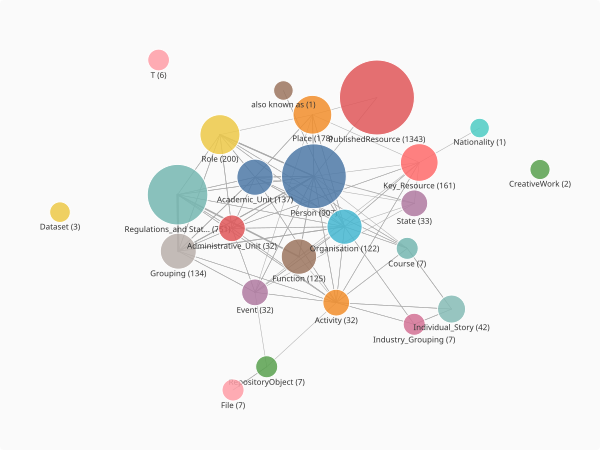

In [241]:
crate.glimpse()

## Entities (nodes)

Explore items in the crate: people, files, places. Each of them has `.properties` (a data
dictionaty) and attribute `.types`.


Get your bearings - what does this graph contain?

In [242]:
crate.entities  # list[Entity] of all nodes

[Entity('CreativeWork', 'ro-crate-metadata.json', id='ro-crate-metadata.json'),
 Entity('CreativeWork', 'Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)', id='https://creativecommons.org/licenses/by-nc-sa/4.0/'),
 Entity('RepositoryObject, DigitalObject, Document', 'The Scholarly, Teaching, Research and Engagement History of The University of Melbourne', id='#D00000001'),
 Entity('File, DigitalObject, Document', 'objects/documents/Appendix 1_2017-03-20 Proposal for VC.pdf', id='objects/documents/Appendix 1_2017-03-20 Proposal for VC.pdf'),
 Entity('RepositoryObject, DigitalObject, Document', 'Joining the Dots and Demonstrating Public Value:\r\nPilot project toward an evidence base for 2020', id='#D00000002'),
 Entity('File, DigitalObject, Document', 'objects/documents/D00000002_Joining the Dots Pilot Project 1 page overview V2 August 3 2018 (1).pdf', id='objects/documents/D00000002_Joining the Dots Pilot Project 1 page overview V2 August 3 2018 (1).pdf'),
 Enti

You can explore an individual entity from this list:

In [243]:
crate.entities[777]

Entity('Regulations_and Statutes', 'UTR7.166 The Olga Lawless Ziegler Memorial Fund', id='#E001213')

Get all file entities:

In [244]:
crate.files

[Entity('File, DigitalObject, Document', 'objects/documents/Appendix 1_2017-03-20 Proposal for VC.pdf', id='objects/documents/Appendix 1_2017-03-20 Proposal for VC.pdf'),
 Entity('File, DigitalObject, Document', 'objects/documents/D00000002_Joining the Dots Pilot Project 1 page overview V2 August 3 2018 (1).pdf', id='objects/documents/D00000002_Joining the Dots Pilot Project 1 page overview V2 August 3 2018 (1).pdf'),
 Entity('File, DigitalObject, Document', 'objects/documents/D00000003_Appendix 2_2018-03-22 Demonstration Project.pdf', id='objects/documents/D00000003_Appendix 2_2018-03-22 Demonstration Project.pdf'),
 Entity('File, DigitalObject, Document', 'objects/documents/D00000004_Agenda_JTD_29August.pdf', id='objects/documents/D00000004_Agenda_JTD_29August.pdf'),
 Entity('File, DigitalObject, Document', 'objects/documents/D00000005_Agenda_JTD_2October.pdf', id='objects/documents/D00000005_Agenda_JTD_2October.pdf'),
 Entity('File, DigitalObject, Document', 'objects/documents/D0000

Get a sorted list of all entity type names present in the graph: 

In [245]:
list(crate.types)

['Academic_Unit',
 'Activity',
 'Administrative_Unit',
 'Article',
 'Book',
 'BookSection',
 'ConferencePaper',
 'Course',
 'CreativeWork',
 'Dataset',
 'DigitalObject',
 'Document',
 'EditedBook',
 'Education',
 'Event',
 'File',
 'Function',
 'Grouping',
 'Individual_Story',
 'Industry_Grouping',
 'Journal',
 'JournalArticle',
 'Key_Resource',
 'Life Event',
 'MAEd thesis',
 'Military',
 'Nationality',
 'NewspaperArticle',
 'Occupation',
 'Organisation',
 'Ormond College',
 'Person',
 'Place',
 'Public Life',
 'PublishedResource',
 'Regulations_and Statutes',
 'Report',
 'RepositoryObject',
 'Residence',
 'Resource',
 'ResourceSection',
 'Role',
 'Scholarships',
 'State',
 'T',
 'Thesis',
 'Trinity College',
 'University of Melbourne',
 'Website',
 'also known as',
 'g',
 'h',
 'i',
 'n']

Get a number of entities (also visisble after calling .profile()):

In [246]:
len(crate)

4270

**Inspecting an indivisual entity:**

In [247]:
e = crate.entities[777]

In [ ]:
print(
    e
)  # I will omit e.id, e.name, e.type, e.types since a user will most likely get all they need
# from the next attribute lookup

Entity('Regulations_and Statutes', 'UTR7.166 The Olga Lawless Ziegler Memorial Fund', id='#E001213')


In [249]:
e.properties

{'identifier': 'E001213',
 'name': 'UTR7.166 The Olga Lawless Ziegler Memorial Fund',
 'alsoKnownAs': [],
 'relatedEvents': [],
 'function': 'Scholarship',
 'processingNotes': '16 October 2018 Alannah Croom. Created entity',
 'recordAppendDate': '2018-10-16 12:00:03',
 'epub': True,
 'online': True,
 'sourceOf': ['#E001213-F000001',
  '#E000226-E001213',
  '#E001373-E001213',
  '#E001377-E001213',
  '#E001392-E001213',
  '#E001393-E001213',
  '#E001409-E001213'],
 'targetOf': ['#E001213-E001373',
  '#E001213-E000226',
  '#E001213-E001409',
  '#E001213-E001377',
  '#E001213-E001392',
  '#E001213-E001393']}

Get a specific entity by id:

In [250]:
crate.get("#E001213")

Entity('Regulations_and Statutes', 'UTR7.166 The Olga Lawless Ziegler Memorial Fund', id='#E001213')

Get an entity and its live reference to the graph. EntityView class is used in annotate_entities() method.

In [251]:
e2 = crate.entity_view("#E001213")

You can call help() around an object, if things become unclear:

In [252]:
help(e2)

Help on EntityView in module crategraph.core.views object:

class EntityView(builtins.object)
 |  EntityView(entity: 'Entity', graph: 'Graph | None' = None) -> 'None'
 |
 |  An entity made graph-aware for ``annotate_entities`` callables.
 |
 |  Methods defined here:
 |
 |  __init__(self, entity: 'Entity', graph: 'Graph | None' = None) -> 'None'
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __repr__(self) -> 'str'
 |      Return repr(self).
 |
 |  get(self, key: 'str', default: 'Any' = None) -> 'Any'
 |      Shorthand for ``properties.get(key, default)`` — preferred in lambdas.
 |
 |  has(self, rel: 'str', direction: 'str' = 'out') -> 'bool'
 |
 |  parse_date(self, *fields: 'str') -> 'TemporalValue | None'
 |      Parse the named date *fields* in order; return the first that parses.
 |
 |      The explicit, field-specific counterpart to the :attr:`year` /
 |      :attr:`start_date` *default policy*: it reads **only** the fields you
 |      name (no cascad

In [253]:
e2.properties

mappingproxy({'identifier': 'E001213',
              'name': 'UTR7.166 The Olga Lawless Ziegler Memorial Fund',
              'alsoKnownAs': [],
              'relatedEvents': [],
              'function': 'Scholarship',
              'processingNotes': '16 October 2018 Alannah Croom. Created entity',
              'recordAppendDate': '2018-10-16 12:00:03',
              'epub': True,
              'online': True,
              'sourceOf': ['#E001213-F000001',
               '#E000226-E001213',
               '#E001373-E001213',
               '#E001377-E001213',
               '#E001392-E001213',
               '#E001393-E001213',
               '#E001409-E001213'],
              'targetOf': ['#E001213-E001373',
               '#E001213-E000226',
               '#E001213-E001409',
               '#E001213-E001377',
               '#E001213-E001392',
               '#E001213-E001393']})

**Discover all property keys** 


If you want to explore property values in your graph, these are the ways to approach it:

In [254]:
all_names = set()
for e in crate.entities:
    all_names.update(e.properties)
sorted(all_names)

['about',
 'abstract',
 'alsoKnownAs',
 'author',
 'birthPlace',
 'birthState',
 'catalogueId',
 'contains',
 'contentLanguage',
 'dateAccessed',
 'dateModifier',
 'deathPlace',
 'deathState',
 'description',
 'descriptionOfWork',
 'dobject',
 'dobjectIdentifier',
 'dovorder',
 'endDate',
 'endDateISOString',
 'endDateModifier',
 'entity',
 'epub',
 'fapplies',
 'format',
 'fullNote',
 'function',
 'gallery',
 'gender',
 'hasFile',
 'identifier',
 'name',
 'nationality',
 'notes',
 'number',
 'numberOfPages',
 'numberOfVolumes',
 'online',
 'place',
 'preparedBy',
 'processingNotes',
 'publicationDate',
 'publicationYear',
 'publisher',
 'recordAppendDate',
 'recordLastModified',
 'reference',
 'referenceSource',
 'relatedEvents',
 'resourceCreator',
 'secondaryAuthor',
 'secondaryTitle',
 'sourceOf',
 'startDate',
 'startDateISOString',
 'startDateModifier',
 'subName',
 'summaryNote',
 'targetOf',
 'url',
 'urlType',
 'volume']

In [255]:
sorted({k for e in crate.entities for k in e.properties})

['about',
 'abstract',
 'alsoKnownAs',
 'author',
 'birthPlace',
 'birthState',
 'catalogueId',
 'contains',
 'contentLanguage',
 'dateAccessed',
 'dateModifier',
 'deathPlace',
 'deathState',
 'description',
 'descriptionOfWork',
 'dobject',
 'dobjectIdentifier',
 'dovorder',
 'endDate',
 'endDateISOString',
 'endDateModifier',
 'entity',
 'epub',
 'fapplies',
 'format',
 'fullNote',
 'function',
 'gallery',
 'gender',
 'hasFile',
 'identifier',
 'name',
 'nationality',
 'notes',
 'number',
 'numberOfPages',
 'numberOfVolumes',
 'online',
 'place',
 'preparedBy',
 'processingNotes',
 'publicationDate',
 'publicationYear',
 'publisher',
 'recordAppendDate',
 'recordLastModified',
 'reference',
 'referenceSource',
 'relatedEvents',
 'resourceCreator',
 'secondaryAuthor',
 'secondaryTitle',
 'sourceOf',
 'startDate',
 'startDateISOString',
 'startDateModifier',
 'subName',
 'summaryNote',
 'targetOf',
 'url',
 'urlType',
 'volume']

**Exporting results to pandas / polars**

If you want to visualise/export your data to a Dataframe, import pandas (or polars if you prefer) first:

In [256]:
import pandas as pd

In [257]:
pd.DataFrame(crate.entity_records())  # all enties in the graph (one row per entity)

,id,label,type,types,about,identifier,name,description,endDate,endDateISOString,...,secondaryAuthor,numberOfVolumes,volume,referenceSource,numberOfPages,number,abstract,catalogueId,descriptionOfWork,contains
0,ro-crate-metadata.json,ro-crate-metadata.json,CreativeWork,[CreativeWork],./,ro-crate-metadata.json,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://creativecommons.org/licenses/by-nc-sa/...,Attribution-NonCommercial-ShareAlike 4.0 Inter...,CreativeWork,[CreativeWork],NaN,NaN,Attribution-NonCommercial-ShareAlike 4.0 Inter...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,#D00000001,"The Scholarly, Teaching, Research and Engageme...",RepositoryObject,"[RepositoryObject, DigitalObject, Document]",NaN,D00000001,"The Scholarly, Teaching, Research and Engageme...",Proposal to the Vice‐Chancellor of The Univers...,12 March 2017,2017-03-12 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,objects/documents/Appendix 1_2017-03-20 Propos...,objects/documents/Appendix 1_2017-03-20 Propos...,File,"[File, DigitalObject, Document]",NaN,NaN,objects/documents/Appendix 1_2017-03-20 Propos...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,#D00000002,Joining the Dots and Demonstrating Public Valu...,RepositoryObject,"[RepositoryObject, DigitalObject, Document]",NaN,D00000002,Joining the Dots and Demonstrating Public Valu...,"For Chancellery Engagement, Advancement and th...",3 August 2018,2018-08-03 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4265,#P00001349,About Us,PublishedResource,"[PublishedResource, ResourceSection]",NaN,P00001349,About Us,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4266,#P00001350,History,PublishedResource,"[PublishedResource, ResourceSection]",NaN,P00001350,History,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4267,ohrm/data,ohrm/data,Dataset,[Dataset],NaN,NaN,ohrm/data,The Microsoft Access MDB files.,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4268,ohrm/web,ohrm/web,Dataset,[Dataset],NaN,NaN,ohrm/web,The OHRM website data files.,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Export this data into an Excel

In [258]:
pd.DataFrame(crate.entity_records()).sort_values("startDate").to_csv("allrecords.csv", index=False)

In [259]:
!open "allrecords.csv"

In [260]:
pd.DataFrame(
    crate.entity_records(columns=["id", "name", "type"])
)  # filter out by property keys of interest

,id,name,type
0,ro-crate-metadata.json,NaN,CreativeWork
1,https://creativecommons.org/licenses/by-nc-sa/...,Attribution-NonCommercial-ShareAlike 4.0 Inter...,CreativeWork
2,#D00000001,"The Scholarly, Teaching, Research and Engageme...",RepositoryObject
3,objects/documents/Appendix 1_2017-03-20 Propos...,objects/documents/Appendix 1_2017-03-20 Propos...,File
4,#D00000002,Joining the Dots and Demonstrating Public Valu...,RepositoryObject
...,...,...,...
4265,#P00001349,About Us,PublishedResource
4266,#P00001350,History,PublishedResource
4267,ohrm/data,ohrm/data,Dataset
4268,ohrm/web,ohrm/web,Dataset


Return a count of distinct values for any property of an entity (sorted by highest count, descending):

In [261]:
crate.entity_counts("function")

function,count
Scholarship,259
Research Fund,57
Prize,36
Bursary,28
"Memorial, Scholarship",28
Bequest,22
Fellowship,22
"Bequest, Research Fund",20
Chair Endowment,20
Award,19


In [262]:
crate.entity_counts("type")

type,count
PublishedResource,1343
Person,907
Regulations_and Statutes,751
Role,200
Place,178
Key_Resource,161
Academic_Unit,137
Grouping,134
Function,125
Organisation,122


**Filter a graph property**

Find all the lawyers in the graph:

In [263]:
crate.where(function="Lawyer")

Graph(13 entities, 0 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

Find all the entries for this date period (inclusive);

In [264]:
crate.where(startDate=(1870, 1900))

Graph(70 entities, 130 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

**Enrich**


Select all people born im Victoria in this crate. You can start with exploring types of entities in the graph: list(crate.types) to find where that is represented.

First, see what Victoria is linked to:  

In [265]:
crate.annotate_entities(place=lambda e: e.related("birthPlace").first("name")).entity_counts(
    "place"
)

place,count
Melbourne,19
University of Melbourne,8
Sydney,6
St Kilda,5
Ballarat,4
"University of Melbourne, Parkville",4
Caulfield,3
Glasgow,3
Kew,3
London,3


In [266]:
crate.annotate_entities(state=lambda e: e.related("birthState").first("name")).entity_counts(
    "state"
)

state,count
Victoria,98
New South Wales,12
County Cork,3
Tasmania,3
Yorkshire,3
London,2
Oxforshire,2
Queensland,2
South Australia,2
Sussex,2


Now that we know Victoria is a property of a birthState, we can add a new property to entities:

In [267]:
crate2 = crate.annotate_entities(
    is_victorian=lambda e: e.related("birthState").first("name") == "Victoria"
)

In [268]:
len(crate2.where(is_victorian=True))

98

Find out the top hub entities in this graph (10 by default, adjust n to your preference).

In [269]:
crate.most_connected(n=3)

[(Entity('Regulations_and Statutes', 'Chapter R6, Prizes, Exhibitions, Scholarships and Bursaries', id='#E000100'),
  417),
 (Entity('Function', 'Scholarship', id='#F000001'), 331),
 (Entity('Regulations_and Statutes', 'Chapter R7, Endowments Other Than Those of Prizes, Exhibitions and Scholarships', id='#E001373'),
  321)]

##  Relationships (edges)

Directed links between entities. Each has a `.type`, `.source`, `.target`.

**Look around**

Have a look at what relationships exist in the graph:

In [ ]:
# crate.relationships  # returns a list of all relationship objects in the graph
list(crate.relationship_types)  # returns distinct relationship type names

['Previous',
 'Primary',
 'Related',
 'Relationship',
 'Subsequent',
 'alsoKnownAs',
 'birthPlace',
 'birthState',
 'deathPlace',
 'deathState',
 'dobject',
 'entity',
 'hasFile',
 'nationality',
 'place',
 'preparedBy',
 'relatedEvents']

Visualise a single relationship object in a graph:

In [271]:
print(crate.relationships[111])

Relationship('#E000018' --deathState--> '#Victoria')


**Count and export**

Return a count of how many relationships exist for each relationship type (sorted by highest count, descending):

In [272]:
crate.relationship_counts("type")

type,count
Related,9743
Relationship,1249
entity,358
relatedEvents,358
preparedBy,261
birthPlace,176
birthState,152
deathPlace,126
deathState,120
Previous,12


In [273]:
import pandas as pd

pd.DataFrame(crate.relationship_records())

,source,target,type,rel_id,description,identifier,name,recordAppendDate,recordLastModified,ordering,...,preparedBy,endDate,endDateISOString,reorder,startDate,startDateISOString,startDateModifier,endDateModifer,dateQualifier,processingNotes
0,#D00000001,objects/documents/Appendix 1_2017-03-20 Propos...,hasFile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,objects/documents/Appendix 1_2017-03-20 Propos...,#D00000001,dobject,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,#D00000002,objects/documents/D00000002_Joining the Dots P...,hasFile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,objects/documents/D00000002_Joining the Dots P...,#D00000002,dobject,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,#D00000003,objects/documents/D00000003_Appendix 2_2018-03...,hasFile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12596,#E002053,#E002109,Related,#E002109-E002053,NaN,E002109-E002053,"Education -> Relationship, Related -> Departme...",2019-08-12 13:46:55,2019-08-12 13:46:57,NaN,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
12597,#E002057,#E002110,Related,#E002110-E002057,NaN,E002110-E002057,"Community Based Health -> Relationship, Relate...",2019-08-12 13:50:33,2019-08-12 13:50:36,NaN,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
12598,#E002056,#E002110,Related,#E002110-E002056,NaN,E002110-E002056,"School Based Health -> Relationship, Related -...",2019-08-12 13:50:40,2019-08-12 13:50:44,NaN,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
12599,#E002054,#E002110,Related,#E002110-E002054,NaN,E002110-E002054,"Hospital Based Health -> Relationship, Related...",2019-08-12 13:50:54,2019-08-12 13:50:57,NaN,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN


**Filter/match by edge type** (use `select`)

Find entities connected by "Primary" relationship:

In [274]:
crate.select(relationship_types="Primary")

Graph(10 entities, 15 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

You can find entities connected by multiple relationship types:

In [275]:
crate.select(relationship_types=["Previous", "Related"])

Graph(2206 entities, 9767 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

Anything connected via "Previous" edge (source/target)

In [276]:
crate2 = crate.pattern(via="preparedBy")

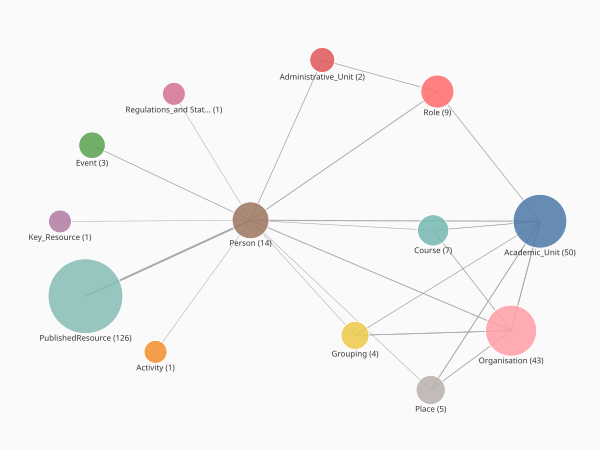

In [277]:
crate2.glimpse()

In [278]:
print(len(crate2), "entities")
# print(len(crate2.relationships), "relationships")

266 entities


**Enrich / reshape edges**


Can't come up with a meaningful example of annotate_relationships()

In [279]:
crate_simple = crate.collapse_edges()  # not sure how to show this so it's practically useful?

##  File content

The actual data files attached to file-entities.

>Going to leave this for now together with build_semantic_index()


In [280]:
len(crate.files)

10

##  Graph manipulations (produces a new graph each time)

**Filter / subset** 

Select specific information in a graph. Select a certain entity type:

In [290]:
people = crate.select(entity_types=["Person"])

...a certain time period:

In [291]:
mid_cent = crate.select(time_range=(1945, 1960))

..or most connected entities:

In [295]:
crate.select(min_connections=20)

Graph(79 entities, 128 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

You can also leave out certain information. Exclude a certain entity/relationship type:

In [298]:
crate.exclude(relationship_types="Related")

Graph(3274 entities, 2858 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

...or drop some property values:

In [304]:
crate.drop("#Elizabeth Daniels", property="preparedBy")

Graph(4201 entities, 12532 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

We can see that the .drop() method returns a graph with 4201 entities, while the opposite .where() method returns 69 entities. Together they form the original graph of 4270 entities.

In [373]:
crate_ed = crate.where(preparedBy="#Elizabeth Daniels")

In [370]:
crate_ed

Graph(69 entities, 0 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

You can take out entities of one graph from another one using substract() method:

In [377]:
crate.substract(crate_ed)

Graph(4201 entities, 12532 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

Search (free text) for an entity in a graph. Default minimum rapidfuzz match score set to 80, but can be adjusted - as well as the number of entities displayed:

In [315]:
crate.search("Elisabet")

Found 120 match(es) for "Elisabet":

  100  #A000722  (summaryNote: Murdoch Children's Research Institute (MCRI) is the largest child health rese...)
  100  #E000539  (summaryNote: In June 1996, Dame Elisabeth Murdoch donated $200,000 to the Victorian Colleg...)
  100  #E000540  (summaryNote: In December 1998, Dame Elisabeth Murdoch donated $250,000 to the Victorian Co...)
  100  #E000541  (summaryNote: The fund called the 'The Keith and Elisabeth Murdoch Travelling Fellowship (A...)
  100  #E000569  (fullNote: In 1996, the Victorian College of the Arts commenced an appeal to raise funds...)
  100  #E000599  (name: Kava, Elisabeth)
  100  #P00000755  (name: UTR6.237 - The Keith and Elisabeth Murdoch Travelling Fellowship (Drama))
  100  #P00000756  (name: UTR6.238 - The Keith and Elisabeth Murdoch Travelling Fellowship (Art))
   88  #A000718  (processingNotes: 2019-01-08 Elizabeth Daniels
Created this grouping after a discussion with G...)
   88  #E000001  (processingNotes: 13 August 2

Graph(120 entities, 73 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

In [317]:
crate.search("Elisabeth", threshold=90, top_n=3)

Found 8 match(es) for "Elisabeth":

  100  #A000722  (summaryNote: Murdoch Children's Research Institute (MCRI) is the largest child health rese...)
  100  #E000539  (summaryNote: In June 1996, Dame Elisabeth Murdoch donated $200,000 to the Victorian Colleg...)
  100  #E000540  (summaryNote: In December 1998, Dame Elisabeth Murdoch donated $250,000 to the Victorian Co...)
  ... and 5 more


Graph(8 entities, 0 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

**Transform** 


Raw string dates (like "1985", "c.1920s", or "1 March 2003") can be converted to ISO date strings:

In [329]:
crate_dates = crate.convert_dates()

convert_dates: parsed 1643/1643 entities with date fields (100%).


...or this can be performed on explicit fields of interest:

In [326]:
crate.convert_dates(start="startDate", end="endDate")

convert_dates: parsed 1553/1553 entities with date fields (100%).


Graph(4270 entities, 12601 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

Unsure how to use merge_nodes() meaningfully...?

In [335]:
overview = crate.merge_nodes(by="type")
overwiew = crate.merge_nodes(by="organisation")

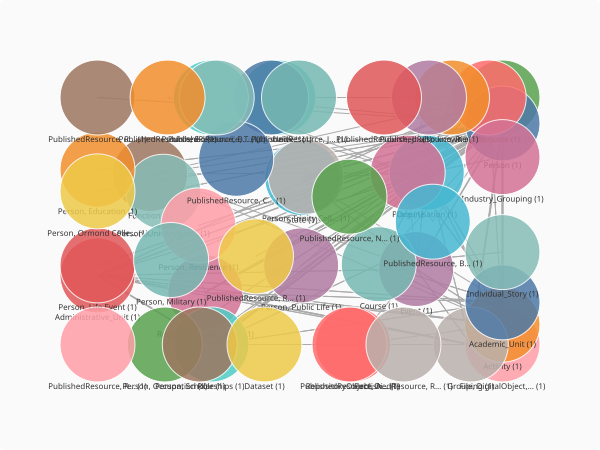

In [336]:
overview.glimpse()

Add a community property to a graph:

In [344]:
communities = crate.detect_communities()

In [346]:
communities.visualise(colour_by="community", filepath="communities.html")

'communities.html'

In [347]:
!open "communities.html"

In [343]:
communities.where(community=7)

Graph(5 entities, 5 relationships, source='/Users/oreln/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Documents/cdl2-rocrates-data/UMPC-ro-crate')

**Visualising and exporting a graph**


Default renderer for exporting an interactive network in visualise() method is "2d" (sigma.js WebGL). Other options: "3d" 3d-force-graph, "svg" static SVG, "pyvis" pyvis/vis.js (needs extra install)

In [348]:
crate.visualise(filepath="mycrate.html")

'mycrate.html'

Open your network visualisation:

In [349]:
!open "mycrate.html"

In [352]:
crate.visualise(renderer="3d", filepath="3dcrate.html")

'3dcrate.html'

Not sure if colour_by/size_by is useful here...

In [355]:
crate.visualise(colour_by="community", size_by="year", filepath="newcrate.html")

'newcrate.html'

In [356]:
!open "newcrate.html"

You can export a GraphML to visualise it in Gephi or Cytoscape:

In [368]:
crate.write("crate_export.graphml", format="graphml")

FileExistsError: crate_export.graphml

Leaving these out as I don't quite know how to use/explain them:

crate.expand(...)                         
crate.query("(a:Person)-[:author]->(b)")   
crate.simplify()   
crate.layout()             # 2D node positions


detect_communities() is something that I don't quite find useful - feel free to delete/or lets discuss sometime

## Experiments


> **📝 Recipes:** _examples here_
